# ORM Jacobian — Pure Quadrupoles (ALBA-II)

Tensor convention: axis 0 = quadrupole, axis 1 = BPM, axis 2 = corrector.

In [22]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path("../scripts")))

from general_numerical import NumericalCalculation
from ACalORAT import AnaORM, plot_utils, math_utils

## Parameters

In [23]:
calc = NumericalCalculation("ring_a2", {
    "direction" : "both",
    "elements"  : "quad",
    "linearize" : -1,
    "fringes"   : True,
    "dispersion": True,
    "step"      : 1e-6,
}, root=Path("../"))

calc.compute()

Found existing case 0 matching parameters.
Loading cached results for case 0.


## Analytical

In [19]:
ring, ind = calc.ring, calc.ind

cORM_v = AnaORM.AnaORM(ring, "v", ind)
cORM_v.assign_optics()
ana_v = cORM_v.dRij_dqk_thick23(cORM_v.bpm, cORM_v.cor, cORM_v.quad)

cORM_h = AnaORM.AnaORM(ring, "h", ind)
cORM_h.assign_optics()
ana_h = cORM_h.dRij_dqk_thick23(cORM_h.bpm, cORM_h.cor, cORM_h.quad)
#ana_h += cORM_h.dRij_dqk_thick23_disp(cORM_h.bpm, cORM_h.cor, cORM_h.quad)

## Results

Vertical   nRMSE per element (mitjana): 0.01%
Horizontal nRMSE per element (mitjana): 0.05%


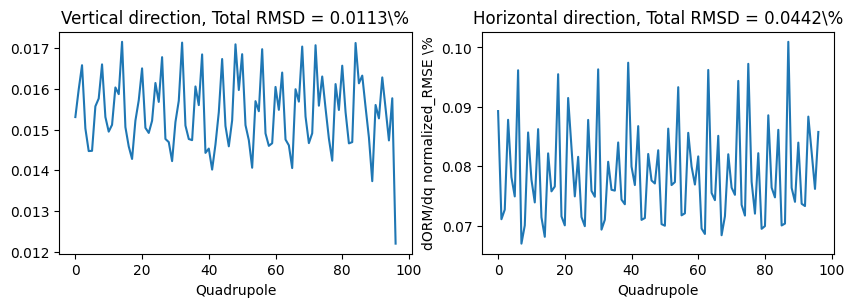

In [20]:
num_v = calc.numerical("v")
num_h = calc.numerical("h")

err_v = math_utils.normalized_RMSE(num_v, ana_v, dims=(1, 2))
err_h = math_utils.normalized_RMSE(num_h, ana_h, dims=(1, 2))
print(f"Vertical   nRMSE per element (mitjana): {err_v.mean():.2f}%")
print(f"Horizontal nRMSE per element (mitjana): {err_h.mean():.2f}%")

plot_utils.plot_both_Zeus(num_v, num_h, ana_v, ana_h, xlabel="Quadrupole")